# Ocean-Atmosphere heat budget

In order to properly identify the wartming and cooling regions along the Antarctic Shelf,I we need to include the heat exchange with the atmosphere. This notebook will do the ocean-atmospheric budget between the heat accumulation by the ocean and the heat loss at the atmosphere to check where the model shows warming and cooling happening

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d

import xarray as xr
import cf_xarray as cfxr

In [2]:
client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 28,Total memory: 251.20 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45829,Workers: 7
Dashboard: /proxy/8787/status,Total threads: 28
Started: Just now,Total memory: 251.20 GiB
Comm: tcp://127.0.0.1:40807,Total threads: 4
Dashboard: /proxy/41159/status,Memory: 35.89 GiB
Nanny: tcp://127.0.0.1:33019,


### Part I -  Calculating heat loss to the Atmosphere

In [3]:
#Initial setting

exp01 = 'panant-01-zstar-ACCESSyr2'
exp005 = 'panant-005-zstar-ACCESSyr2'
exp0025 = 'panant-0025-zstar-ACCESSyr2'

lat_range = slice(-90,-59)
start_time='2000-01'
end_time='2000-12'
time_slice=slice(start_time,end_time)


session = cc.database.create_session()
session_BU = cc.database.create_session('/home/156/wf4500/databases/access/panan_BU.db')

#We will need the cell areas to calculate the heat loss in W instead of W/m2
TAREA_01 = cc.querying.getvar(exp01,'areacello',session,n=-1).sel(yh=lat_range).chunk(chunks={'yh':510,'xh':360})
TAREA_005 = cc.querying.getvar(exp005,'areacello',session,n=-1).sel(yh=lat_range).chunk(chunks={'yh':1019,'xh':360})
TAREA_0025 = cc.querying.getvar(exp0025,'areacello',session_BU,n=-1).sel(yh=lat_range).chunk(chunks={'yh':2038,'xh':360})

In [4]:
#Importing heat transport in W/m2, anc converting it to W
var='hfds' # [W/m2] You will need to confirm if this is the correct variable to use here

#Importing heat loss to atm - panan-01
Hatm_01 = cc.querying.getvar(exp01,var,session,frequency='1 monthly',start_time=start_time,end_time=\
                             end_time).sel(time=time_slice).sel(yh=lat_range).mean('time').chunk(chunks={'yh':510,'xh':360})*TAREA_01

#Importing heat loss to atm- panan-005
Hatm_005 = cc.querying.getvar(exp005,var,session,frequency='1 monthly',start_time=start_time,end_time=\
                             end_time).sel(time=time_slice).sel(yh=lat_range).mean('time').chunk(chunks={'yh':1019,'xh':360})*TAREA_005

#Importing heat loss to atm- panan-0025
Hatm_0025 = cc.querying.getvar(exp0025,var,session_BU,frequency='1 monthly',start_time=start_time,end_time=\
                             end_time).sel(time=time_slice).sel(yh=lat_range).mean('time').chunk(chunks={'yh':2038,'xh':360})*TAREA_0025


/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.07/lib/python3.10/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.07/lib/python3.10/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.07/lib/python3.10/site-packages/xarray/core/dataset.py:278: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/g/data/hh5/public/apps/miniconda3/envs/analysis3-23.07/lib/python3

Our budget will be comprised of anything coming into the shelf from offshore (calculated by the CSHT), any zonal re-organization of the heat in the shelf ( Zonal convergence) and any heat loss to atmosphere only along the shelf. So the next steps here would be:

1- Mask regions north of the shelf

2- Bin the shelf in 3 degrees longitude bins

3- Sum all ocean-atm heat exchange in that bin, south of the shelf. 

Let's do it then...

**For $0.1^o$:**

In [5]:
	print("importing isobath mask for panan-01")
	#outfile = '/g/data/v45/akm157/model_data/access-om2/Antarctic_slope_contour_'+str(isobath_depth)+'m.npz'
	outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan01_1000m.npz'
	data = np.load(outfile)
	
	yh = cc.querying.getvar(exp01,'yh',session,n=1)
	yh = yh.sel(yh=lat_range)
	xh = cc.querying.getvar(exp01,'xh',session,n=1)
	
	mask01 =xr.DataArray(data['contour_masked_above']).assign_coords({"dim_0": np.array(yh),"dim_1": np.array(xh)}).rename(dim_0="yh",dim_1="xh")
	mask01 = (mask01.where(mask01>=0)*0)+1
	print("Using panan-01 mask to isolate the shelf in heat exchange")
	Hatm_01 = Hatm_01.where(mask01==1)

importing isobath mask for panan-01
Using panan-01 mask to isolate the shelf in heat exchange


**For $0.05^o$:**

In [6]:
	print("importing isobath mask for panan-005")
	#outfile = '/g/data/v45/akm157/model_data/access-om2/Antarctic_slope_contour_'+str(isobath_depth)+'m.npz'
	outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan005_1000m.npz'
	data = np.load(outfile)
	
	yh = cc.querying.getvar(exp005,'yh',session,n=1)
	yh = yh.sel(yh=lat_range)
	xh = cc.querying.getvar(exp005,'xh',session,n=1)
	
	mask005 =xr.DataArray(data['contour_masked_above']).assign_coords({"dim_0": np.array(yh),"dim_1": np.array(xh)}).rename(dim_0="yh",dim_1="xh")
	mask005 = (mask005.where(mask005>=0)*0)+1
	print("Using panan-005 mask to isolate the shelf in heat exchange")
	Hatm_005 = Hatm_005.where(mask005==1)

importing isobath mask for panan-005
Using panan-005 mask to isolate the shelf in heat exchange


**For $0.025^o$:**

In [7]:
	print("importing isobath mask for panan-0025")
	#outfile = '/g/data/v45/akm157/model_data/access-om2/Antarctic_slope_contour_'+str(isobath_depth)+'m.npz'
	outfile = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/contours/Antarctic_slope_contour_Panan0025_1000m.npz'
	data = np.load(outfile)
	
	yh = cc.querying.getvar(exp0025,'yh',session_BU,n=1)
	yh = yh.sel(yh=lat_range)
	xh = cc.querying.getvar(exp0025,'xh',session_BU,n=1)
	
	mask0025 =xr.DataArray(data['contour_masked_above']).assign_coords({"dim_0": np.array(yh),"dim_1": np.array(xh)}).rename(dim_0="yh",dim_1="xh")
	mask0025 = (mask0025.where(mask0025>=0)*0)+1
	print("Using panan-0025 mask to isolate the shelf in heat exchange")
	Hatm_0025 = Hatm_0025.where(mask0025==1)

importing isobath mask for panan-0025
Using panan-0025 mask to isolate the shelf in heat exchange


**Step 1 is done**, next on, we need to do steps 1 and 2 together. Lets import the lon and lat bins so we can use for reference for the binning

In [8]:
# Since binned midpoints are the same for all regions, we dont need to import it more than once
lon_midpoints  = xr.open_dataset('/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/' + \
                                   'panan01/CSHT_daily_z/Ant_cross_slope_heat_terms_offline_1000m_2000-01.nc').lon_bin_midpoints

In [9]:
West_lon_midpoints=lon_midpoints-1.5 #western edge of bins'
East_lon_midpoints=lon_midpoints+1.5 #western edge of bins

Next, summing up data along bins. Points in the western edge of each bin will be included in each bin ( shown by the **>=**)

In [10]:
Hatm_01.load()
Hatm_005.load()
Hatm_0025.load()

<xarray.DataArray (yh: 2038, xh: 14400)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * xh       (xh) float64 -280.0 -280.0 -279.9 -279.9 ... 79.94 79.96 79.99
  * yh       (yh) float64 -81.09 -81.08 -81.07 -81.06 ... -59.03 -59.01 -59.0

In [11]:
%%time
Hatm_01_binned=np.zeros(np.shape(lon_midpoints))
Hatm_005_binned=np.zeros(np.shape(lon_midpoints))
Hatm_0025_binned=np.zeros(np.shape(lon_midpoints))
for n in range(int(np.size(lon_midpoints))):
    Hatm_01_binned[n]=Hatm_01.where((Hatm_01.xh>=West_lon_midpoints[n]) & (Hatm_01.xh<East_lon_midpoints[n])).sum()
    Hatm_005_binned[n]=Hatm_005.where((Hatm_005.xh>=West_lon_midpoints[n]) & (Hatm_005.xh<East_lon_midpoints[n])).sum()
    Hatm_0025_binned[n]=Hatm_0025.where((Hatm_0025.xh>=West_lon_midpoints[n]) & (Hatm_0025.xh<East_lon_midpoints[n])).sum()


CPU times: user 3min 23s, sys: 2min 4s, total: 5min 27s
Wall time: 4min 53s


Does the heat loss to the atmosphere change between resolutions?

In [12]:
factor01=0.08
factor005=0.08
factor0025=0.08

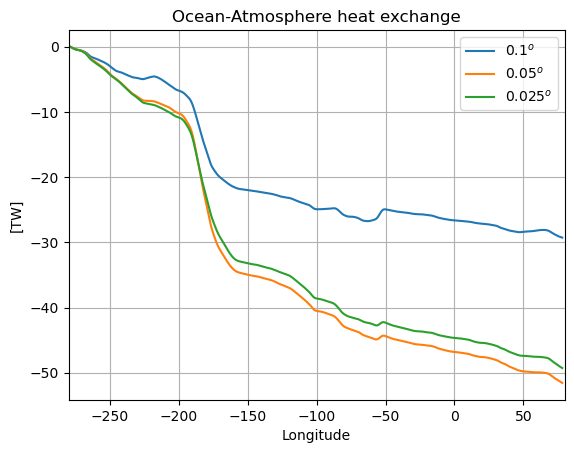

In [13]:
plt.plot(lon_midpoints,Hatm_01_binned.cumsum()*factor01/1e12,label=r"$0.1^o$")
plt.plot(lon_midpoints,Hatm_005_binned.cumsum()*factor005/1e12,label=r"$0.05^o$")
plt.plot(lon_midpoints,Hatm_0025_binned.cumsum()*factor0025/1e12,label=r"$0.025^o$")
plt.xlim(-280,80); plt.xlabel('Longitude')
plt.ylabel('[TW]')
plt.grid()
plt.title('Ocean-Atmosphere heat exchange')
plt.legend()

### Part II -  Discounting heat loss from the shelf heat budget

In [14]:
#panan01 daily as f(z,time)
src_p01 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan01/CSHT_daily_z/*'
#panan005 daily as f(z,time)
src_p005 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan005/CSHT_daily_z/*'
#panan0025 daily as f(z,time)
src_p0025 = '/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/Processed_data/panan0025/CSHT_monthly_z/*'

lat_slice  = slice(-83,-59)

figdir='/home/156/wf4500/v45_wf4500/Project_panan/GH/Panan_HT_ASC/figs/'

In [15]:
#importing panan01
import glob
gl =glob.glob(src_p01)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p01_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

#importing panan005
gl =glob.glob(src_p005)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p005_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested').rename({'zl':'z_l'})

#importing panan0025 - THIS IS AMONTHLY DATA
gl =glob.glob(src_p0025)
gl=sorted(gl)
print("%i netcdf data files"%len(gl))
p0025_HT=xr.open_mfdataset(gl, concat_dim='time', combine='nested')
#matching time  for climatological means
p0025_HT['time']=np.array(p0025_HT.time+1)

12 netcdf data files
12 netcdf data files
12 netcdf data files


Calculating actual factors for correct budget

In [16]:
#for panan01
p01_HT_mean=p01_HT.mean('time')
factor01 = ((p01_HT_mean.unbinned_heat_transp_across_contour.sum()) / (p01_HT_mean.binned_cross_slope_heat_trans.sum() +\
                                                                      p01_HT_mean.zonal_convergence.sum())).values

#for panan005
p005_HT_mean=p005_HT.mean('time')
factor005 = ((p005_HT_mean.unbinned_heat_transp_across_contour.sum()) / (p005_HT_mean.binned_cross_slope_heat_trans.sum() +\
                                                                      p005_HT_mean.zonal_convergence.sum())).values

#for panan0025
p0025_HT_mean=p0025_HT.mean('time')
factor0025 = ((p0025_HT_mean.unbinned_heat_transp_across_contour.sum()) / (p0025_HT_mean.binned_cross_slope_heat_trans.sum() +\
                                                                      p0025_HT_mean.zonal_convergence.sum())).values


The ocean budget for each resolution will be the **$(binned\ cross\ slope\ heat\ trans\ +\ zonal\ convergence)*factor/1e12$**

In [17]:
#for panan01
ocean01_HB= ( p01_HT_mean.binned_cross_slope_heat_trans.sum('z_l') + p01_HT_mean.zonal_convergence.sum('z_l') )*factor01/1e12
#for panan005
ocean005_HB= ( p005_HT_mean.binned_cross_slope_heat_trans.sum('z_l') + p005_HT_mean.zonal_convergence.sum('z_l') )*factor005/1e12
#for panan0025
ocean0025_HB= ( p0025_HT_mean.binned_cross_slope_heat_trans.sum('z_l') + p0025_HT_mean.zonal_convergence.sum('z_l') )*factor0025/1e12

Text(0, 0.5, '[TW]')

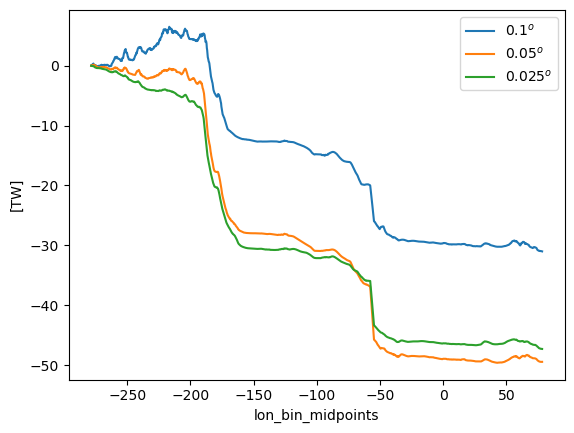

In [18]:
#Checking them...
ocean01_HB.cumsum().plot(label=r"$0.1^o$")
ocean005_HB.cumsum().plot(label=r"$0.05^o$")
ocean0025_HB.cumsum().plot(label=r"$0.025^o$")
plt.legend()
plt.ylabel('[TW]')

It looks like the ones we calculated before. Lets discoint the heat loss from atmosphere to obtain the shelf budget

In [19]:
#for panan01
ShelfHB_01 = (ocean01_HB - (Hatm_01_binned*factor01/1e12))
ShelfHB_005 = (ocean005_HB - (Hatm_005_binned*factor005/1e12))
ShelfHB_0025 = (ocean0025_HB - (Hatm_0025_binned*factor0025/1e12))

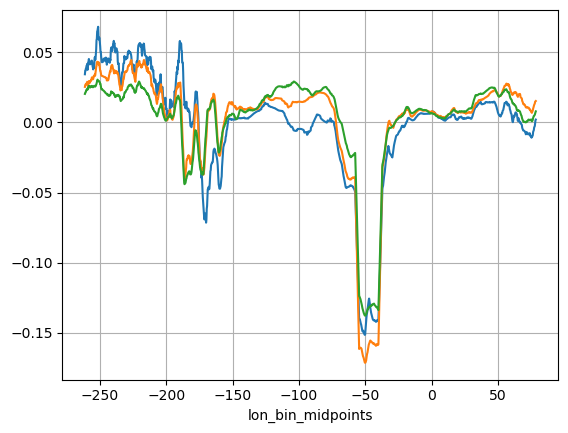

In [20]:
#we will use a rolling mean t smooth the data
rmw=70 # rolling mean window
ShelfHB_01.rolling(lon_bin_midpoints=rmw).mean().plot(label=r"$0.1^o$")
ShelfHB_005.rolling(lon_bin_midpoints=rmw).mean().plot(label=r"$0.05^o$")
ShelfHB_0025.rolling(lon_bin_midpoints=rmw).mean().plot(label=r"$0.025^o$")
plt.grid()

ok, this does not seem correct at all to me.... should I talk to adele about that?

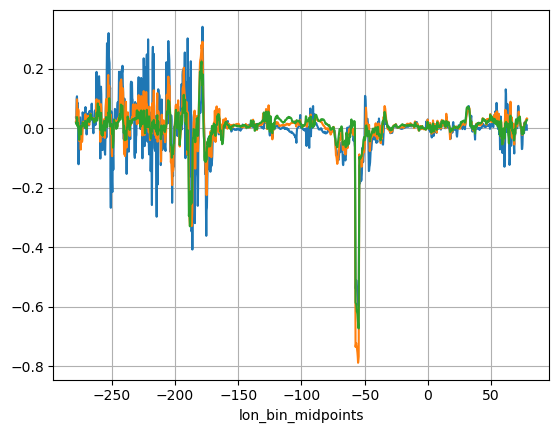

In [21]:
#we will use a rolling mean t smooth the data
rmw=2 # rolling mean window
ShelfHB_01.rolling(lon_bin_midpoints=rmw).mean().plot(label=r"$0.1^o$")
ShelfHB_005.rolling(lon_bin_midpoints=rmw).mean().plot(label=r"$0.05^o$")
ShelfHB_0025.rolling(lon_bin_midpoints=rmw).mean().plot(label=r"$0.025^o$")
plt.grid()